<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab M1: Discontinuity

## Setup

In [37]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

## Sales Experience

### Business Decision

Reynolds Products is assessing the effectiveness of its new sales staff, which is hired contigent on sales performance during an intial 90-day probation period.  Management suspects that average daily sales for an individual salesperson increases with experience during and beyond the probation period.

Assume that you are the manager of new hire sales for Reynolds Products.  What do you think about the effectiveness of the probation period for new new salespeople?

### Data

Retrieve a dataset from file 'Reynolds.csv'.  Show the first few observations.
Visualize the dataset as a scatterplot.

Employed,Sales
41,275
106,316
76,327
100,376
22,162
12,150
85,367
111,318
40,189
51,235


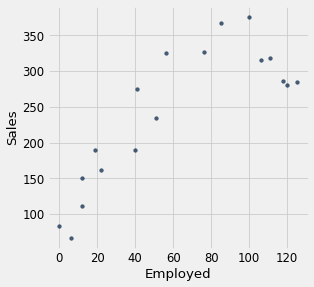

In [38]:
data = Table().read_table('Reynolds.csv')
data
data.scatter('Employed')

### Analysis: One-Piece Model

Build a linear regression model to predict a salesperson's average sales based on number of days employed.
Show the model goodness of fit (R^2).  
Show the model parameters.

In [39]:
model = ols('Sales ~ Employed', data).fit()
model.rsquared
model.params

0.67345340978899471

Intercept    132.059592
Employed       1.786298
dtype: float64

Add a variable for the predicted average sales. 
Add a variable for the prediction errors. _(these are called "residuals", use the .resid function)_

In [40]:
data = data.with_columns('sales_predicted', model.predict(data),
                         'error', model.resid)
data

Employed,Sales,sales_predicted,error
41,275,205.298,69.7022
106,316,321.407,-5.40714
76,327,267.818,59.1818
100,376,310.689,65.3106
22,162,171.358,-9.35814
12,150,153.495,-3.49516
85,367,283.895,83.1051
111,318,330.339,-12.3386
40,189,203.511,-14.5115
51,235,223.161,11.8392


RMSE is $\textit{sqrt}(\textit{mean}(\textit{error}^2))$.  It is a measure of predictive peformance, similar to R^2.

Show the RMSE calculated based on the dataset.  
Visualize the model performance as a scatterplot of average sales and predicted average sales vs. number of days employed.

53.638391397656797

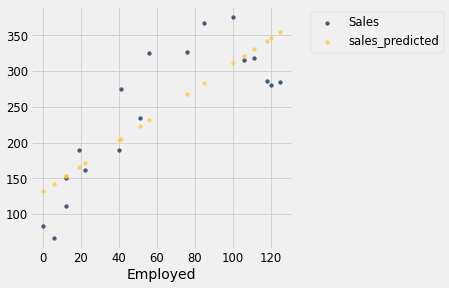

In [41]:
RMSE = sqrt(mean(data.column('error')**2))
RMSE
data.select('Sales','sales_predicted','Employed').scatter('Employed')

#### Predict

Predict the average sales of a salesperson that has been employed for 80 days.

In [42]:
model.predict(Table().with_columns('Employed', 80))

0    274.963399
dtype: float64

### Analysis: Two-Piece Model

Reset the dataset to include only average sales and number of days employed variables.  
Visualize the dataset as a scatterplot.

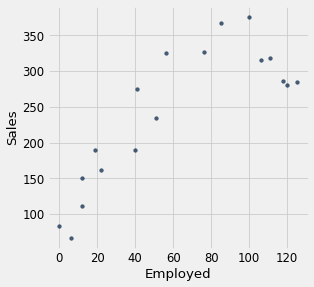

In [43]:
data = data.select('Employed','Sales')
data.scatter('Employed')

Set the breakpoint to 90.  This is the predictor variable value at which an apparent discontinuity occurs.

In [44]:
breakpoint = 90
breakpoint

90

#### Model 1

Filter the dataset to include only sales associated with number of days employed less than or equal to the breakpoint.  
Show the resulting filtered dataset.

In [45]:
data1 = data.where('Employed', are.below_or_equal_to(breakpoint))
data1.show()

Employed,Sales
41,275
76,327
22,162
12,150
85,367
40,189
51,235
0,83
12,112
6,67


Build a linear regression model to predict a salesperson's average sales based on number of days employed (use the filtered dataset).  
Show the model goodness of fit (R^2).  
Show the model parameters.

In [46]:
model1 = ols('Sales ~ Employed', data1).fit()
model1.rsquared
model1.params

0.90269954407746134

Intercept    87.445688
Employed      3.408695
dtype: float64

#### Model 2

Filter the (unfiltered) data to include only sales associated with number of days employed greater than the breakpoint.  
Show the resulting filtered dataset.

In [47]:
data2 = data.where('Employed', are.above(breakpoint))
data2.show()

Employed,Sales
106,316
100,376
111,318
120,280
118,286
125,285


Build a linear regression model to predict a salesperson's average sales based on number of days employed (use the filtered dataset).  
Show the model goodness of fit (R^2).  
Show the model parameters.

In [48]:
model2 = ols('Sales ~ Employed', data2).fit()
model2.rsquared
model2.params

0.83007614947921016

Intercept    709.069044
Employed      -3.519727
dtype: float64

#### Recombine

Add a variable for predicted sales to each filtered dataset.  
Add a variable for errors to each filtered dataset.  
Build a new dataset that combines the filtered datasets.  
Show the resulting dataset.

In [49]:
data1 = data1.with_columns('sales_predicted', model1.predict(data1), 'error', model1.resid)
data2 = data2.with_columns('sales_predicted', model2.predict(data2), 'error', model2.resid)
data_combo = data1.with_rows(data2.rows)

data_combo.show()

Employed,Sales,sales_predicted,error
41,275,227.202,47.7978
76,327,346.506,-19.5065
22,162,162.437,-0.43697
12,150,128.35,21.65
85,367,377.185,-10.1847
40,189,223.793,-34.7935
51,235,261.289,-26.2891
0,83,87.4457,-4.44569
12,112,128.35,-16.35
6,67,107.898,-40.8979


Show the RMSE calculated based on the new dataset.  
Visualize the performance of the 2-piece model as a scatterplot of average sales and predicted average sales
vs. number of days employed.

25.543699705600478

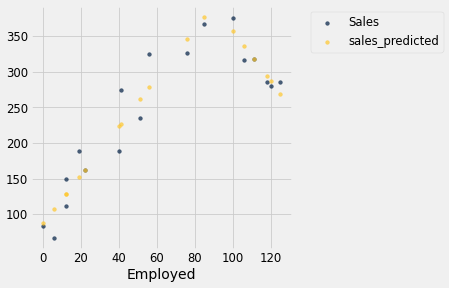

In [50]:
RMSE = sqrt(mean(data_combo.column('error')**2))
RMSE
data_combo.select('Employed','Sales','sales_predicted').scatter('Employed')

#### Predict

Predict the average sales of a salesperson that has been employed for 80 days.

In [51]:
model1.predict(Table().with_columns('Employed', 80))

0    360.141258
dtype: float64

Predict the average sales of a salesperson that has been employed for 100 days.

In [52]:
model2.predict(Table().with_columns('Employed', 100))

0    357.096358
dtype: float64

### Analysis: Piecewise Model

Reset dataset to include average sales and number of days employed variables only.
Visualize the dataset as a scatterplot.

In [53]:
data = data.select('Employed','Sales')
data

Employed,Sales
41,275
106,316
76,327
100,376
22,162
12,150
85,367
111,318
40,189
51,235


Set the breakpoint to 90.  This is the predictor variable value at which an apparent discontinuity occurs.  
Add a variable to the datset for switching (1 means number of days employed is greater than breakpoint, 0 means otherwise).  
Add a variable to the dataset for adjustment, like this: $(\textit{number of days employed} - \textit{breakpoint}) \times \textit{switch}$  
Show the resulting dataset.

In [54]:
breakpoint= 90
data = data.with_column('switch', (data.column('Employed') > breakpoint).astype(int))
data = data.with_column('adjust', (data.column('Employed')-breakpoint)*data.column('switch'))
data.show()

Employed,Sales,switch,adjust
41,275,0,0
106,316,1,16
76,327,0,0
100,376,1,10
22,162,0,0
12,150,0,0
85,367,0,0
111,318,1,21
40,189,0,0
51,235,0,0


Build a linear regression model to predict a salesperson's average sales based on number of days employed and an adjustment.  
Show the model goodness of fit (R^2).  
Show the model parameters.

In [55]:
model = ols('Sales ~ Employed + adjust', data).fit()
model.rsquared
model.params

0.92593104098832457

Intercept    87.596059
Employed      3.401903
adjust       -6.977300
dtype: float64

Add a variable to the dataset for predicted sales.  Show the resulting dataset.

In [56]:
data = data.with_column('sales_predicted', model.predict(data))
data.show()

Employed,Sales,switch,adjust,sales_predicted
41,275,0,0,227.074
106,316,1,16,336.561
76,327,0,0,346.141
100,376,1,10,358.013
22,162,0,0,162.438
12,150,0,0,128.419
85,367,0,0,376.758
111,318,1,21,318.684
40,189,0,0,223.672
51,235,0,0,261.093


Show the RMSE calculated based on the dataset.
Visualize the performance of the model as a scatterplot of average sales and predicted average sales
vs. number of days employed.

25.545904769111171

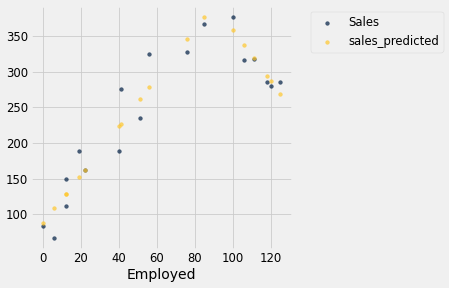

In [57]:
RMSE = sqrt(mean(model.resid**2))
RMSE
data.select('Employed','Sales', 'sales_predicted').scatter('Employed')

Predict the average sales of a salesperson that has been employed for 80 days.

In [58]:
model.predict(Table().with_columns('Employed', 80, 'adjust', (100-breakpoint)*0))

0    359.748269
dtype: float64

Predict the average sales of a salesperson that has been employed for 100 days.

In [59]:
model.predict(Table().with_columns('Employed', 100, 'adjust', (100-breakpoint)*1))

0    358.013325
dtype: float64

Predict the average sales of a salesperson that has been employed for 90 days.

In [60]:
model.predict(Table().with_columns('Employed', 90, 'adjust', (90-breakpoint)*0))
model.predict(Table().with_columns('Employed', 90, 'adjust', (90-breakpoint)*1))

0    393.767296
dtype: float64

0    393.767296
dtype: float64

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised November 18, 2023
</span>
</p>